# BTC Up/Down Prediction-Market DQN — Results

Loads the Phase 0 episode dataset, trains two DQN configurations (different
learning rates) **inline**, and compares them against a principled **fair-value**
baseline on a held-out chronological test split. All P&L is at **fee = 0**
(an upper bound: "is there exploitable signal?").

Pipeline code lives in the `btcdqn/` package. Build the dataset first with
`python build_data.py`.

In [1]:
import os, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from btcdqn import config as C, data, env as E, baseline as B, metrics as M, dqn as D
plt.rcParams["figure.figsize"] = (9, 4)

## 1. Phase 0 dataset

In [2]:
eps, manifest = data.load()
print("episodes:", manifest.market_id.nunique(), "| rows:", len(eps))
summary = manifest.groupby("split", observed=True).agg(
    markets=("market_id", "size"), up_rate=("label_up", "mean")).reindex(["train","val","test"])
for sp in ["train","val","test"]:
    s = manifest[manifest.split == sp]
    summary.loc[sp, "from"] = str(pd.to_datetime(s.H.min(), unit="s").date())
    summary.loc[sp, "to"]   = str(pd.to_datetime(s.H.max(), unit="s").date())
print(summary.to_string())

episodes: 1609 | rows: 96540
       markets   up_rate        from          to
split                                           
train     1126  0.500000  2025-12-27  2026-02-20
val        241  0.514523  2026-02-20  2026-03-03
test       242  0.491736  2026-03-03  2026-03-30


## 2. Baseline policies

In [3]:
sigma = B.estimate_sigma_per_min(eps[eps.split == "train"])
print("sigma_per_min (train) =", round(sigma, 5))
baselines = {
    "random":          B.RandomPolicy(),
    "always_up":       B.AlwaysSidePolicy(E.BUY_UP),
    "always_down":     B.AlwaysSidePolicy(E.BUY_DOWN),
    "fairval_t0":      B.FairValuePolicy(tier=0, threshold=0.05),
    "fairval_t1":      B.FairValuePolicy(tier=1, threshold=0.05, sigma_per_min=sigma),
    "fairval_t1+exit": B.FairValuePolicy(tier=1, threshold=0.05, sigma_per_min=sigma, exit_on_converge=True),
}

sigma_per_min (train) = 0.00078


## 3. Train two DQN configurations (inline)

We train two otherwise-identical DQNs that differ only in **learning rate**, so
the comparison isolates that one hyperparameter. Training uses CPU (the network is
tiny, so CPU is faster than MPS here). Bump `EPOCHS` for a longer run.

In [4]:
EPOCHS = 6
configs = [
    {"label": "lr=1e-3", "lr": 1e-3, "hidden": 64},
    {"label": "lr=2e-4", "lr": 2e-4, "hidden": 64},
]
runs = []
for cfg in configs:
    t0 = time.time()
    out = D.train(eps, manifest, epochs=EPOCHS, lr=cfg["lr"], hidden=cfg["hidden"],
                  device="cpu", label=cfg["label"], verbose=True)
    print(f"  -> {cfg['label']} trained in {time.time()-t0:.0f}s\n")
    runs.append(out)
# keep the better-on-val config's weights on disk for reuse
best_run = max(runs, key=lambda o: o["history"].val_mean_pnl.max())
best_run["agent"].save(C.DQN_CKPT)
print("saved best config to", os.path.basename(C.DQN_CKPT))

[lr=1e-3] epoch  1 | eps=0.736 | train_meanR=+0.1200 | val_meanPnL=+1.0345 sharpe=+2.094
[lr=1e-3] epoch  2 | eps=0.472 | train_meanR=+0.3921 | val_meanPnL=+0.9912 sharpe=+2.008
[lr=1e-3] epoch  3 | eps=0.208 | train_meanR=+0.6568 | val_meanPnL=+1.0119 sharpe=+1.944
[lr=1e-3] epoch  4 | eps=0.050 | train_meanR=+0.9153 | val_meanPnL=+1.0604 sharpe=+2.140
[lr=1e-3] epoch  5 | eps=0.050 | train_meanR=+0.9593 | val_meanPnL=+1.0336 sharpe=+2.091
[lr=1e-3] epoch  6 | eps=0.050 | train_meanR=+0.9463 | val_meanPnL=+1.0598 sharpe=+2.216
  -> lr=1e-3 trained in 236s

[lr=2e-4] epoch  1 | eps=0.736 | train_meanR=+0.1568 | val_meanPnL=+1.0496 sharpe=+2.041
[lr=2e-4] epoch  2 | eps=0.472 | train_meanR=+0.4524 | val_meanPnL=+1.1145 sharpe=+2.186
[lr=2e-4] epoch  3 | eps=0.208 | train_meanR=+0.7247 | val_meanPnL=+1.0845 sharpe=+2.111
[lr=2e-4] epoch  4 | eps=0.050 | train_meanR=+0.9982 | val_meanPnL=+1.1118 sharpe=+2.217
[lr=2e-4] epoch  5 | eps=0.050 | train_meanR=+1.0516 | val_meanPnL=+1.1221 sharp

## 4. Training curves (validation per epoch)

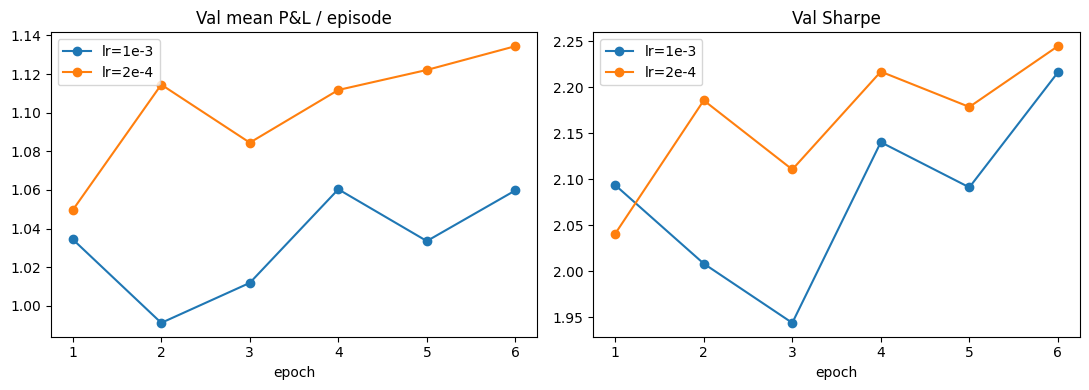

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for out in runs:
    h = out["history"]
    ax[0].plot(h.epoch, h.val_mean_pnl, marker="o", label=out["label"])
    ax[1].plot(h.epoch, h.val_sharpe, marker="o", label=out["label"])
ax[0].set(title="Val mean P&L / episode", xlabel="epoch"); ax[0].legend()
ax[1].set(title="Val Sharpe", xlabel="epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Test comparison: DQN configs vs baselines

         policy  episodes total_pnl mean_pnl sharpe  n_trades trade_rate pnl_per_trade win_rate
         random       242     +8.76  +0.0362 +0.121      4253       100%       +0.0021    42.9%
      always_up       242     -1.67  -0.0069 -0.014       242       100%       -0.0069    49.2%
    always_down       242     +2.64  +0.0109 +0.022       242       100%       +0.0109    50.8%
     fairval_t0       242     +2.64  +0.0109 +0.022       241       100%       +0.0109    50.2%
     fairval_t1       242    +17.70  +0.0731 +0.151       242       100%       +0.0731    52.9%
fairval_t1+exit       242   +104.51  +0.4318 +0.964      1462       100%       +0.0715    75.4%
  DQN (lr=1e-3)       242   +235.97  +0.9751 +2.203      3354       100%       +0.0704    75.1%
  DQN (lr=2e-4)       242   +258.02  +1.0662 +2.252      3579       100%       +0.0721    77.8%


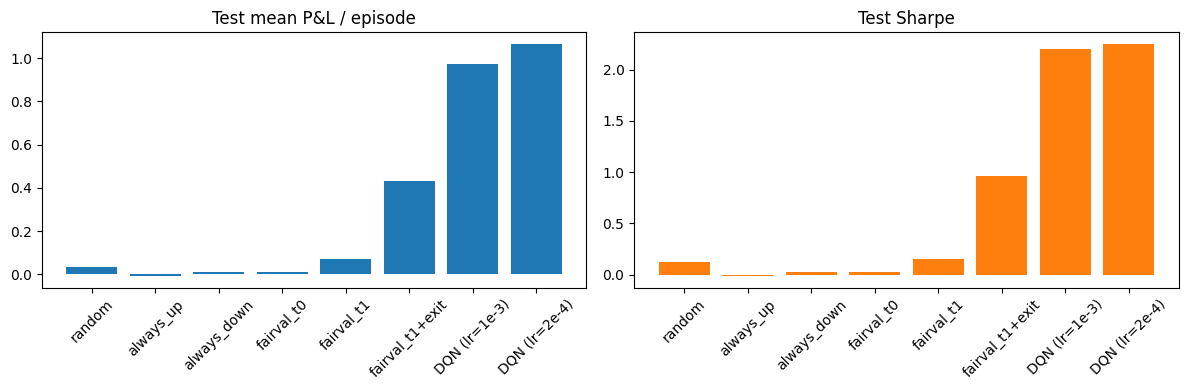

In [6]:
results = []
for name, pol in baselines.items():
    r = M.run_backtest(pol, eps, manifest, "test", fee_rate=0.0); r["name"] = name
    results.append(r)
agent_by_name = {}
for out in runs:
    name = f"DQN ({out['label']})"
    r = M.run_backtest(D.GreedyPolicy(out["agent"]), eps, manifest, "test", fee_rate=0.0)
    r["name"] = name; results.append(r); agent_by_name[name] = out["agent"]
print(M.metrics_table(results))

names = [r["name"] for r in results]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(names, [r["mean_pnl"] for r in results]); ax[0].set(title="Test mean P&L / episode")
ax[1].bar(names, [r["sharpe"] for r in results], color="tab:orange"); ax[1].set(title="Test Sharpe")
for a in ax: a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 6. Best DQN: cumulative P&L over test episodes

best DQN config: DQN (lr=2e-4)


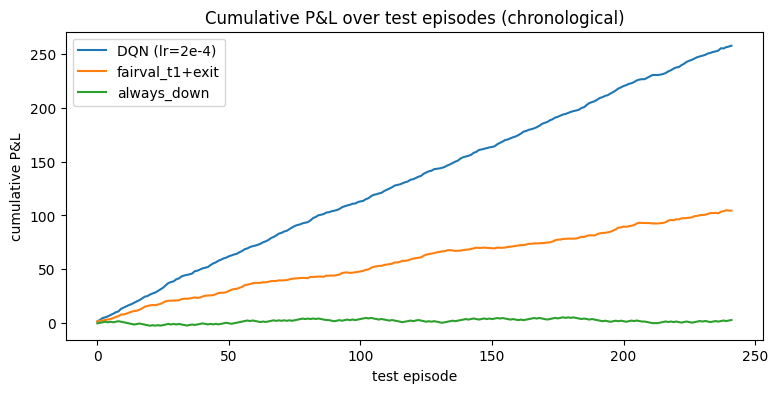

In [7]:
res_by = {r["name"]: r for r in results}
dqn_names = [n for n in res_by if n.startswith("DQN")]
best_name = max(dqn_names, key=lambda n: res_by[n]["mean_pnl"])
best_agent = agent_by_name[best_name]
best_gp = D.GreedyPolicy(best_agent)
print("best DQN config:", best_name)

plt.figure()
for name in [best_name, "fairval_t1+exit", "always_down"]:
    plt.plot(np.cumsum(res_by[name]["_pnls"]), label=name)
plt.legend(); plt.title("Cumulative P&L over test episodes (chronological)")
plt.xlabel("test episode"); plt.ylabel("cumulative P&L"); plt.show()

## 7. Fair-value calibration (test)

    bin    n  pred_fv  actual_up
0.0-0.1 1763    0.027      0.020
0.1-0.2  837    0.151      0.105
0.2-0.3 1072    0.251      0.130
0.3-0.4 1426    0.353      0.232
0.4-0.5 2132    0.455      0.375
0.5-0.6 2411    0.541      0.576
0.6-0.7 1216    0.646      0.756
0.7-0.8  935    0.750      0.848
0.8-0.9  810    0.848      0.912
0.9-1.0 1918    0.975      0.994


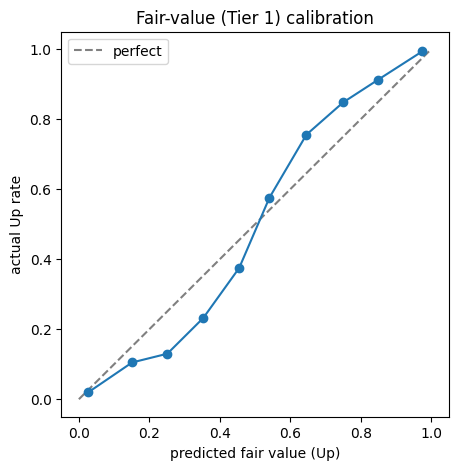

In [8]:
fv = B.FairValuePolicy(tier=1, threshold=0.05, sigma_per_min=sigma)
cal = M.fair_value_calibration(fv, eps, manifest, "test")
print(cal.to_string(index=False))
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
plt.plot(cal.pred_fv, cal.actual_up, marker="o")
plt.xlabel("predicted fair value (Up)"); plt.ylabel("actual Up rate")
plt.title("Fair-value (Tier 1) calibration"); plt.legend(); plt.show()

## 8. Best-DQN behavior: action mix & entry timing

action counts: {'buy_up': 1543, 'close': 3390, 'buy_down': 2036, 'resolve': 189}


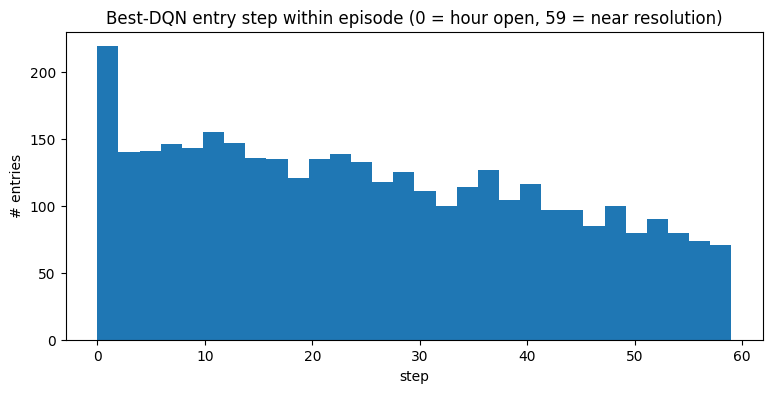

In [9]:
test_mids = manifest[manifest.split == "test"]
labels = dict(zip(manifest.market_id, manifest.label_up))
by = {mid: df for mid, df in eps[eps.market_id.isin(set(test_mids.market_id))].groupby("market_id")}

entry_steps, act_counts = [], {}
for mid in test_mids.market_id:
    res = E.run_policy(E.EpisodeEnv(by[mid], labels[mid]), best_gp)
    for t in res["trades"]:
        act_counts[t["act"]] = act_counts.get(t["act"], 0) + 1
        if t["act"] in ("buy_up", "buy_down"):
            entry_steps.append(t["step"])
print("action counts:", act_counts)
plt.figure(); plt.hist(entry_steps, bins=30)
plt.title("Best-DQN entry step within episode (0 = hour open, 59 = near resolution)")
plt.xlabel("step"); plt.ylabel("# entries"); plt.show()

## 9. Example test episode

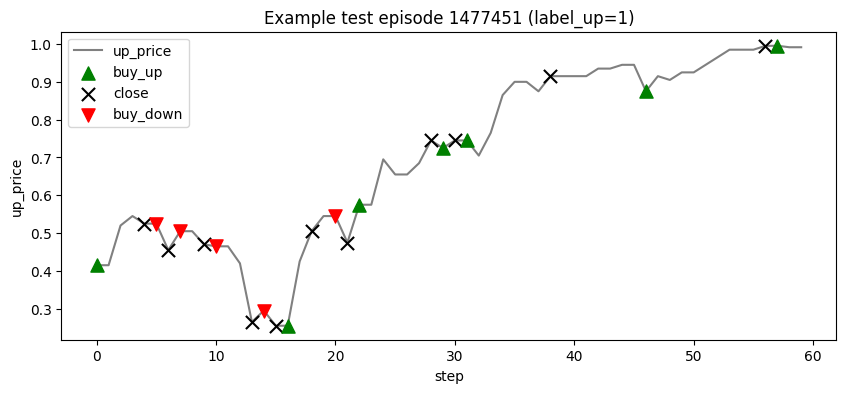

In [10]:
mid = test_mids.market_id.iloc[0]
ep = by[mid].sort_values("step")
res = E.run_policy(E.EpisodeEnv(ep, labels[mid]), best_gp)
up_at = dict(zip(ep.step, ep.up_price_raw))
plt.figure(figsize=(10, 4))
plt.plot(ep.step, ep.up_price_raw, color="gray", label="up_price")
seen = set()
for t in res["trades"]:
    if t["act"] not in ("buy_up", "buy_down", "close"): continue
    m = {"buy_up": ("^", "green"), "buy_down": ("v", "red"), "close": ("x", "black")}[t["act"]]
    lbl = t["act"] if t["act"] not in seen else None; seen.add(t["act"])
    plt.scatter(t["step"], up_at[t["step"]], marker=m[0], color=m[1], s=90, label=lbl, zorder=5)
plt.title(f"Example test episode {mid} (label_up={labels[mid]})")
plt.xlabel("step"); plt.ylabel("up_price"); plt.legend(); plt.show()

## 10. Ablation — fair-value σ sensitivity

Sweep the volatility scale σ around the train estimate and see how test P&L
responds (the calibration above looked slightly compressed toward 0.5).

 sigma_mult  exit  mean_pnl  sharpe  trades
       0.25 False    0.0767   0.157     242
       0.25  True    0.2101   0.449     625
       0.50 False    0.0833   0.170     242
       0.50  True    0.3741   0.783    1161
       0.75 False    0.0785   0.162     242
       0.75  True    0.4515   1.050    1497
       1.00 False    0.0731   0.151     242
       1.00  True    0.4318   0.964    1462
       1.50 False    0.0554   0.115     242
       1.50  True    0.2457   0.541    1201
       2.00 False    0.0216   0.044     242
       2.00  True    0.1316   0.293     987
       3.00 False   -0.0294  -0.061     242
       3.00  True    0.0413   0.092     814


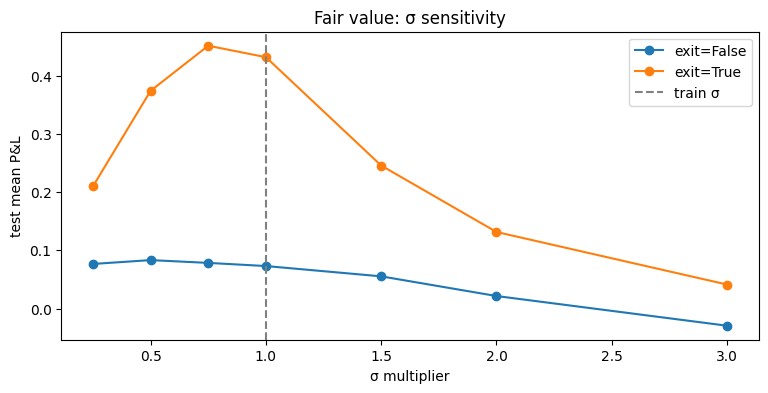

In [11]:
rows = []
for f in [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    sg = sigma * f
    for ex in [False, True]:
        r = M.run_backtest(B.FairValuePolicy(tier=1, threshold=0.05, sigma_per_min=sg,
                                             exit_on_converge=ex), eps, manifest, "test")
        rows.append({"sigma_mult": f, "exit": ex, "mean_pnl": round(r["mean_pnl"], 4),
                     "sharpe": round(r["sharpe"], 3), "trades": r["n_trades"]})
abl_sigma = pd.DataFrame(rows); print(abl_sigma.to_string(index=False))
plt.figure()
for ex in [False, True]:
    d = abl_sigma[abl_sigma.exit == ex]
    plt.plot(d.sigma_mult, d.mean_pnl, marker="o", label=f"exit={ex}")
plt.axvline(1.0, ls="--", color="gray", label="train σ")
plt.xlabel("σ multiplier"); plt.ylabel("test mean P&L"); plt.title("Fair value: σ sensitivity"); plt.legend(); plt.show()

## 11. Ablation — fair-value edge threshold sweep

 threshold  exit  mean_pnl  sharpe  trades
      0.02 False    0.0603   0.123     242
      0.02  True    0.2381   0.520    1160
      0.05 False    0.0731   0.151     242
      0.05  True    0.4318   0.964    1462
      0.10 False    0.0884   0.196     234
      0.10  True    0.4245   1.046     975
      0.15 False    0.0670   0.176     194
      0.15  True    0.2819   0.807     481
      0.20 False    0.0490   0.154     130
      0.20  True    0.1614   0.610     226
      0.30 False    0.0448   0.237      40
      0.30  True    0.0556   0.328      54


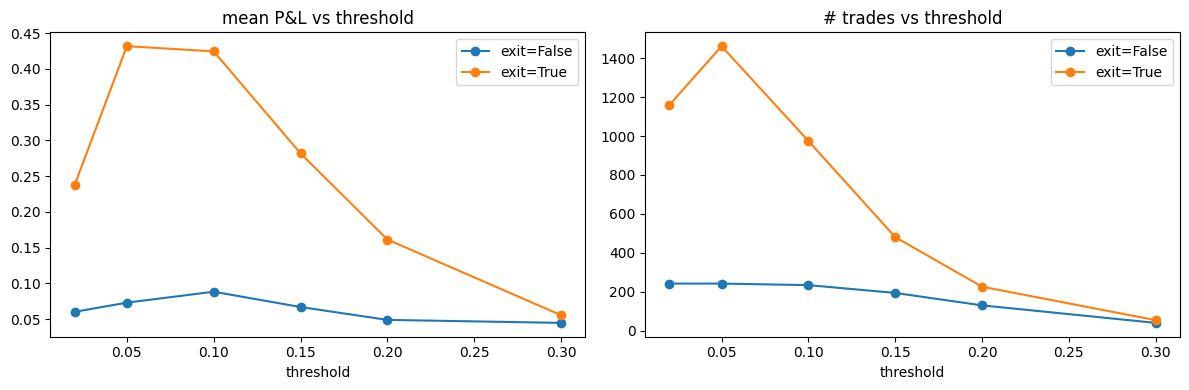

In [12]:
rows = []
for th in [0.02, 0.05, 0.10, 0.15, 0.20, 0.30]:
    for ex in [False, True]:
        r = M.run_backtest(B.FairValuePolicy(tier=1, threshold=th, sigma_per_min=sigma,
                                             exit_on_converge=ex), eps, manifest, "test")
        rows.append({"threshold": th, "exit": ex, "mean_pnl": round(r["mean_pnl"], 4),
                     "sharpe": round(r["sharpe"], 3), "trades": r["n_trades"]})
abl_thr = pd.DataFrame(rows); print(abl_thr.to_string(index=False))
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for ex in [False, True]:
    d = abl_thr[abl_thr.exit == ex]
    ax[0].plot(d.threshold, d.mean_pnl, marker="o", label=f"exit={ex}")
    ax[1].plot(d.threshold, d.trades, marker="o", label=f"exit={ex}")
ax[0].set(title="mean P&L vs threshold", xlabel="threshold"); ax[0].legend()
ax[1].set(title="# trades vs threshold", xlabel="threshold"); ax[1].legend()
plt.tight_layout(); plt.show()

## 12. Takeaways

- The spot-implied **fair value is well-calibrated and profitable**, confirming the
  contract lags spot (the inefficiency thesis); Tier 1 + early-exit is the
  strongest baseline.
- The **DQN beats the baselines** on the held-out test split, trading actively to
  exploit the same convergence signal.
- Comparing the two learning rates shows the effect of that hyperparameter on
  convergence speed and final performance (see the training curves).
- σ and threshold sweeps show the baseline is **robust** across a wide range.
- All results are at **fee = 0** — an upper bound on exploitable signal, not a
  net-of-cost trading claim.